# Step 1: Load Data

In [1]:
import pandas as pd

df = pd.read_csv("Wholesale customers data.csv")
print(df.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


# Step 2: Basic EDA

In [2]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None
          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1.000000    1.000000       3.000000     55.000000      3.000000   
25%      1.000000    2

# Step 3: Drop Irrelevant Features

In [3]:
df = df.drop(['Channel', 'Region'], axis=1)

# Step 4: Scaling

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Step 5: Find Optimal Clusters (Elbow Method)

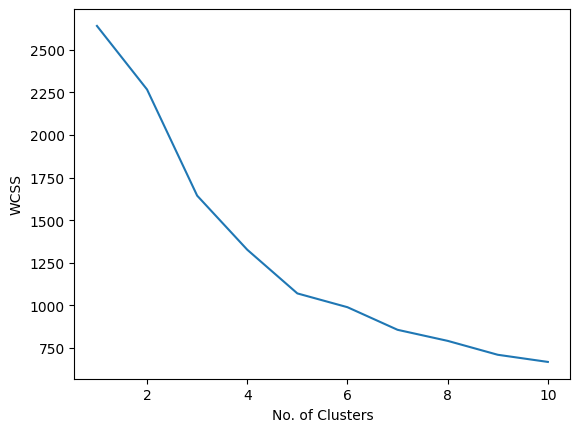

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS")
plt.show()

# Step 6: Build Model

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

# Step 7: Visualization

<Axes: xlabel='Grocery', ylabel='Milk'>

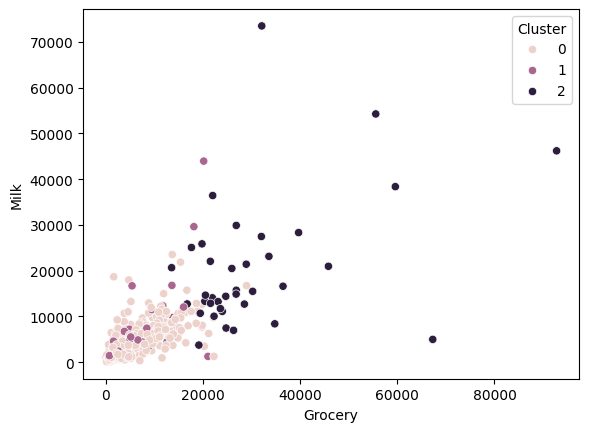

In [8]:
import seaborn as sns

sns.scatterplot(x=df['Grocery'], y=df['Milk'], hue=df['Cluster'])

# Step 8: Evaluation (Unsupervised)

In [9]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_data, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.4582633767207058


# Step 9: Save Model

In [10]:
import pickle

pickle.dump(kmeans, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))